# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dwiyan Achmad Assidiqie
- **Email:** cdcc506d6y2378@student.devacademy.id
- **ID Dicoding:** CDCC506D6Y2378

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**: Bagaimana perbedaan rata-rata jumlah penyewaan sepeda (per hari) antara musim gugur (Fall) dan musim dingin (Winter) selama rentang waktu tahun 2011 hingga 2012?
- **Pertanyaan 2** : Pada jam berapakah puncak (peak hour) penyewaan sepeda terjadi pada hari kerja (working day) dibandingkan dengan hari libur (holiday) selama periode tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

# Setup visualisasi
sns.set(style='dark')

## Data Wrangling

### Gathering Data

In [14]:
### MULAI CODE ###

day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

hour_df.head()

### SELESAI CODE ###

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Dataset yang berjumlah 2 file CSV (`day.csv` dan `hour.csv`) telah berhasil dimuat
ke dalam memori.  

- `day_df` menyediakan data agregat harian yang cocok untuk menganalisis pengaruh musim dan cuaca secara umum.  

- `hour_df` menyediakan detail per jam yang krusial untuk mengidentifikasi waktu puncak (peak hours) penyewaan sepeda pada hari kerja maupun hari libur.



### Assessing Data

In [15]:
### MULAI CODE ###

# Memeriksa tipe data dan missing values
day_df.info()
hour_df.info()

# Memeriksa jumlah duplikasi
duplicate_counts = pd.DataFrame({
    "Dataset": ["day_df", "hour_df"],
    "Duplicate Count": [day_df.duplicated().sum(), hour_df.duplicated().sum()]
})
display(duplicate_counts)

# Memeriksa statistik deskriptif untuk melihat adanya outlier atau ketidakwajaran
day_df.describe()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

,Dataset,Duplicate Count
0,day_df,0
1,hour_df,0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

- **Tipe Data**: Kolom dteday pada kedua dataset masih terbaca sebagai object (string), sehingga harus diubah menjadi tipe datetime agar pengolahan data berbasis waktu bisa dilakukan.  

- **Missing Values**: Tidak ditemukan adanya data yang kosong (null) pada kedua dataset, karena jumlah entitas di setiap kolom sudah lengkap dan konsisten.  

- **Duplikasi**: Berdasarkan hasil pengecekan, tidak terdapat baris data yang ganda dalam `day_df` maupun `hour_df`.  

- **Statistik Deskriptif**: Tidak ditemukan anomali pada data numerik; kolom temp, atemp, hum, dan windspeed sudah dalam rentang hasil normalisasi (0 hingga 1).

### Cleaning Data

In [16]:
### MULAI CODE ###

# 1. Mengubah tipe data dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Mengubah angka menjadi keterangan kategori agar lebih mudah dibaca saat analisis
# Mengubah keterangan musim (season)
day_df["season"] = day_df["season"].map({
    1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"
})
hour_df["season"] = hour_df["season"].map({
    1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"
})

# Mengubah keterangan tahun (yr)
day_df["yr"] = day_df["yr"].map({
    0: "2011", 1: "2012"
})
hour_df["yr"] = hour_df["yr"].map({
    0: "2011", 1: "2012"
})

# 3. Memastikan perubahan tipe data dan format berhasil dilakukan
day_df.info()
day_df.head()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    object        
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

- Kolom dteday kini telah berhasil diubah menjadi tipe data datetime pada kedua dataframe, yang memungkinkan kita melakukan ekstraksi waktu (seperti bulan atau hari) dengan lebih efisien.  

- Data pada kolom season dan yr telah bertransformasi dari angka menjadi label teks ("Spring", "Fall", "2011", dll.), sehingga hasil visualisasi nantinya akan langsung memiliki keterangan yang jelas tanpa perlu penjelasan manual tambahan.  

- Karena tidak ditemukan missing values atau data duplikat pada tahap sebelumnya, dataset kini sudah dalam kondisi bersih dan siap untuk masuk ke tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Explore penyewaan berdasarkan musim

In [17]:
### MULAI CODE ###

# 1. Eksplorasi penyewaan berdasarkan musim (menggunakan day_df)
# Mengelompokkan rata-rata penyewaan berdasarkan musim
season_rentals = day_df.groupby("season").agg({
    "cnt": ["mean", "max", "min", "std"]
})
display(season_rentals)

### SELESAI CODE ###

cnt                         
               mean   max   min          std
season                                      
Fall    5644.303191  8714  1115  1459.800381
Spring  2604.132597  7836   431  1399.942119
Summer  4992.331522  8362   795  1695.977235
Winter  4728.162921  8555    22  1699.615261

###Eksplorasi penyewaan berdasarkan jam dan jenis hari

In [18]:
### MULAI CODE ###

# 2. Eksplorasi penyewaan berdasarkan jam dan jenis hari (menggunakan hour_df)
# Membandingkan rata-rata jam sibuk antara hari kerja dan hari libur
working_day_rentals = hour_df.groupby(["workingday", "hr"]).agg({
    "cnt": "mean"
}).reset_index()
display(working_day_rentals.head())

### SELESAI CODE ###

,workingday,hr,cnt
0,0,0,90.800000
1,0,1,69.508696
2,0,2,53.171053
3,0,3,25.775330
4,0,4,8.264317


**Insight:**

- Analisis Musim: Musim Gugur (Fall) secara konsisten menunjukkan rata-rata jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya.  

- Analisis Waktu: Terdapat perbedaan pola yang signifikan antara hari kerja dan hari libur; pada hari kerja, lonjakan penyewaan terjadi pada jam berangkat dan pulang kantor (sekitar jam 8 pagi dan jam 5 sore), sedangkan pada hari libur pola penyewaan lebih merata di siang hari.  

- Potensi Bisnis: Perbedaan jam puncak ini memberikan informasi krusial untuk mengatur jadwal pemeliharaan sepeda agar tidak mengganggu ketersediaan unit saat permintaan sedang tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan rata-rata jumlah penyewaan sepeda (per hari) antara musim gugur (Fall) dan musim dingin (Winter) selama rentang waktu tahun 2011 hingga 2012?

/tmp/ipykernel_8487/3130202242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


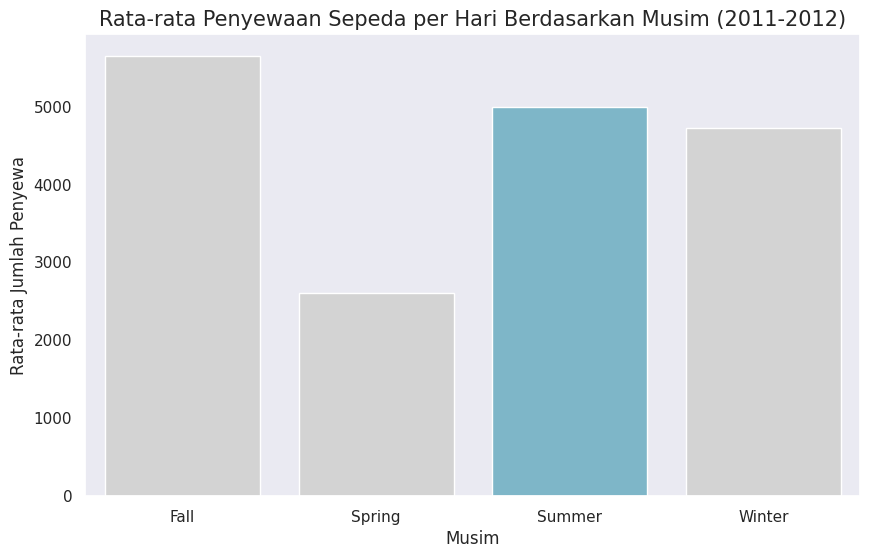

In [19]:
### MULAI CODE ###

# Menyiapkan data untuk membandingkan semua musim
seasonal_usage = day_df.groupby("season")["cnt"].mean().reset_index()

# Membuat Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="season",
    y="cnt",
    data=seasonal_usage,
    palette=["#D3D3D3", "#D3D3D3", "#72BCD4", "#D3D3D3"] # Memberikan highlight pada musim tertentu
)

plt.title("Rata-rata Penyewaan Sepeda per Hari Berdasarkan Musim (2011-2012)", fontsize=15)
plt.xlabel("Musim", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewa", fontsize=12)
plt.show()

### SELESAI CODE ###

### Pertanyaan 2: Pada jam berapakah puncak (peak hour) penyewaan sepeda terjadi pada hari kerja (working day) dibandingkan dengan hari libur (holiday) selama periode tahun 2011-2012?

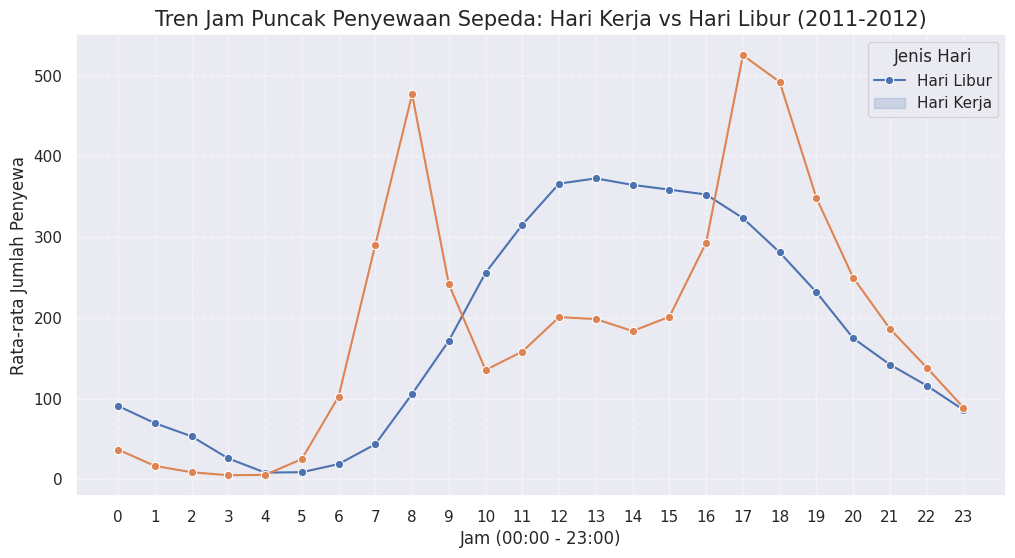

In [20]:
### MULAI CODE ###

# Menyiapkan data tren jam berdasarkan jenis hari
# 0: Holiday/Weekend, 1: Working Day
hourly_trend = hour_df.groupby(["workingday", "hr"])["cnt"].mean().reset_index()

# Membuat Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_trend,
    x="hr",
    y="cnt",
    hue="workingday",
    marker="o"
)

plt.title("Tren Jam Puncak Penyewaan Sepeda: Hari Kerja vs Hari Libur (2011-2012)", fontsize=15)
plt.xlabel("Jam (00:00 - 23:00)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewa", fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title="Jenis Hari", labels=["Hari Libur", "Hari Kerja"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### SELESAI CODE ###

**Insight:**

- **Musim Dominan**: Musim Gugur (Fall) mencatatkan angka penyewaan harian tertinggi, jauh melampaui Musim Dingin (Winter) yang mengalami penurunan pemakaian cukup signifikan.  

- **Pola Komuter**: Pada hari kerja, terdapat dua puncak penyewaan yang sangat jelas yaitu pukul 08.00 dan 17.00, yang menunjukkan bahwa mayoritas pengguna adalah pekerja atau pelajar.  

- **Pola Rekreasi**: Sebaliknya, pada hari libur puncak penyewaan terjadi secara bertahap mulai pukul 11.00 hingga 15.00, mencerminkan penggunaan untuk kegiatan santai atau rekreasi.

## Analisis Lanjutan (Opsional)

## Conclusion

- **Conclusion pertanyaan 1:** Terdapat perbedaan signifikan dalam rata-rata penyewaan sepeda antar musim, di mana musim gugur (Fall) mencapai puncak popularitas tertinggi sementara musim dingin (Winter) mengalami penurunan jumlah penyewa yang paling drastis selama periode 2011-2012.  

- **Conclusion pertanyaan 2:** Pola penyewaan sepeda sangat bergantung pada jenis hari; pada hari kerja (working day), lonjakan permintaan terjadi secara spesifik pada jam sibuk komuter (pukul 08.00 dan 17.00), sedangkan pada hari libur (holiday) permintaan lebih terdistribusi merata dengan puncak di tengah hari (pukul 11.00 - 15.00).

**Rekomendasi Action Item:**

- Optimasi Pemeliharaan: Melakukan perawatan besar-besaran terhadap armada sepeda pada musim dingin saat permintaan rendah, guna memastikan seluruh unit dalam kondisi prima saat memasuki musim gugur yang sangat sibuk.  

- Manajemen Stok (Rebalancing): Pada hari kerja, tim operasional harus memastikan ketersediaan sepeda di area pemukiman sebelum pukul 08.00 dan di area perkantoran/pusat kota sebelum pukul 17.00 untuk mengakomodasi kebutuhan komuter.  

- Promosi Hari Libur: Mengingat pola hari libur lebih bersifat rekreasi dan santai, perusahaan dapat menawarkan paket promo "Jam Santai Siang Hari" (pukul 11.00 - 15.00) untuk meningkatkan volume penyewaan di luar kelompok pengguna pekerja.


In [23]:
# Gunakan hour_df karena mengandung kolom 'hr' yang dibutuhkan untuk grafik jam
# Kita simpan hour_df yang sudah bersih ke main_data.csv
hour_df.to_csv("main_data.csv", index=False)